In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))
import os

os.environ["OMP_NUM_THREADS"] = "1"
%env OMP_NUM_THREADS=1

env: OMP_NUM_THREADS=1


In [3]:
from scikit_quri.qnn.kernel_tsne import quantum_kernel_tsne
import numpy as np
from quri_parts.circuit import H, CZ
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
from scikit_quri.circuit import LearningCircuit
from quri_parts.core.state import quantum_state
from numpy.typing import NDArray
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

n_qubits = 12
depth = 1

def create_quantum_circuit():
    qc = LearningCircuit(n_qubits)

    def preprocess_x(x: NDArray[np.float64], index: int) -> float:
        xa = x[index % len(x)]
        return min(1, max(-1, xa))

    for i in range(n_qubits):
        qc.add_gate(H(i))
    for d in range(depth):
        for i in range(n_qubits):
            qc.add_input_RY_gate(i, lambda x, i=i: preprocess_x(x, i))
        for i in range(n_qubits):
            qc.add_input_RX_gate(i, lambda x, i=i: preprocess_x(x, i))
        if d < depth - 1:
            for i in range(n_qubits):
                qc.add_gate(CZ(i, (i + 1) % n_qubits))
    return qc


# X, Y = load_iris(return_X_y=True)
X, Y = load_digits(return_X_y=True) #XとYにはどのような値がはいっている？
print(X.shape)
print(Y.shape)
X = X / 16.0
n_features = 12
print(X)


(1797, 64)
(1797,)
[[0.     0.     0.3125 ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.625  0.     0.    ]
 [0.     0.     0.     ... 1.     0.5625 0.    ]
 ...
 [0.     0.     0.0625 ... 0.375  0.     0.    ]
 [0.     0.     0.125  ... 0.75   0.     0.    ]
 [0.     0.     0.625  ... 0.75   0.0625 0.    ]]


In [4]:
skf = StratifiedKFold()
for tr_index, te_index in skf.split(X, Y):
    break

X_train = X[tr_index]
X_test = X[te_index]
y_train = Y[tr_index]
y_test = Y[te_index]
print(f"{X_train.shape=}")

pca = PCA(n_components=n_features)
pca.fit(X_train)
X_train = pca.transform(X_train)
X_test = pca.transform(X_test)
print(f"{X_train.shape=}")
print(X_train)

X_train.shape=(1437, 64)
X_train.shape=(1437, 12)
[[ 0.07118438 -1.08519294  0.15593311 ... -0.17608816  0.10479478
   0.15872509]
 [-1.04158825  0.33849451 -0.76507131 ... -0.06724607  0.01676126
  -0.0687557 ]
 [ 0.60276167  1.48955687 -0.8515436  ...  0.02836731  0.06294696
   0.12235595]
 ...
 [ 0.6856696   0.52378104 -0.33924014 ...  0.49753575 -0.59428441
   0.10353829]
 [-0.24015713 -0.83821276  0.4714381  ...  0.66445106 -0.23462283
   0.01405146]
 [-0.05815239 -0.24142882 -0.75662675 ...  0.62930696 -0.76715193
   0.31943238]]


In [5]:
# X_train = X_train / 16.
# X_train = X_train[:200]
# y_train = y_train[:200] #500 => fidelity 81.6[s]
scaler = MinMaxScaler((0, np.pi / 2))


X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[0.79325529, 0.30853224, 0.87094352, ..., 0.61811449, 1.04094836,
        0.95917036],
       [0.354215  , 0.93147651, 0.48649949, ..., 0.69100138, 0.98578791,
        0.79085251],
       [1.00298713, 1.43513179, 0.45040439, ..., 0.75502957, 1.01472716,
        0.93226007],
       ...,
       [1.03569815, 1.01254991, 0.66424918, ..., 1.0692116 , 0.60291608,
        0.91833648],
       [0.67041666, 0.41660013, 1.00264105, ..., 1.18098764, 0.8282745 ,
        0.85212328],
       [0.74222596, 0.67772706, 0.49002441, ..., 1.15745314, 0.49459995,
        1.0780811 ]], shape=(1437, 12))

In [ ]:
qk_tsne = quantum_kernel_tsne(max_iter=5000)
X_train_state = np.zeros(len(X_train), dtype=object)
pqc = create_quantum_circuit()
for i, x in enumerate(X_train):
    # xを調子回路のパラメータとして埋め込んで、その回路によって得られる状態を保存
    X_train_state[i] = quantum_state(
        n_qubits=n_qubits, circuit=pqc.bind_input_and_parameters(x, [])
    )
p_probs = qk_tsne.tsne.calc_probabilities_p_state(X_train_state)
print(f"{p_probs=}")

[0.79325529 0.30853224 0.87094352 1.06117673 1.00057545 1.4150628
 0.94336344 0.76060285 0.82636247 0.61811449 1.04094836 0.95917036]
a [np.float64(0.7932552946997838), np.float64(0.3085322415546207), np.float64(0.8709435186405287), 1, 1, 1, np.float64(0.9433634403216249), np.float64(0.7606028471722367), np.float64(0.8263624688564258), np.float64(0.6181144893714614), 1, np.float64(0.9591703641987469), np.float64(0.7932552946997838), np.float64(0.3085322415546207), np.float64(0.8709435186405287), 1, 1, 1, np.float64(0.9433634403216249), np.float64(0.7606028471722367), np.float64(0.8263624688564258), np.float64(0.6181144893714614), 1, np.float64(0.9591703641987469)]
[0.354215   0.93147651 0.48649949 0.56453882 0.72345294 0.73690472
 1.0432016  0.38182135 1.25219714 0.69100138 0.98578791 0.79085251]
a [np.float64(0.3542150021653529), np.float64(0.9314765137514002), np.float64(0.486499494616906), np.float64(0.5645388169853394), np.float64(0.7234529427902052), np.float64(0.7369047169137133)

KeyboardInterrupt: 

calculating p_ij
 1436/1437
calculating fidelity
 1436/1437elapsed time:6.555259958999159


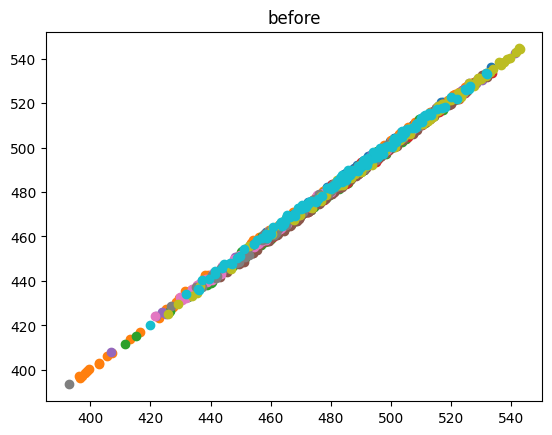

 iter=5000 loss=np.float64(2.626921734717488) message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 1
     fun: 2.6269317001552746
       x: [-7.392e+02 -1.523e+02 ...  7.650e-01  7.065e-01]
     nit: 0
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
    nfev: 5000


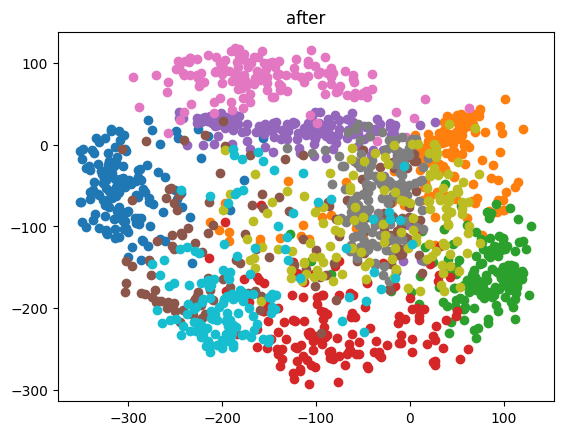

 359/360


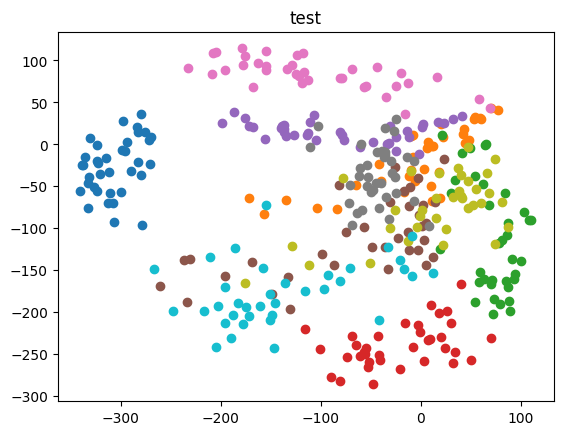

In [17]:
qk_tsne.init(create_quantum_circuit, [])
qk_tsne.train(X_train, y_train, method="Powell")

pred_y = qk_tsne.transform(X_test)
qk_tsne.plot(pred_y, y_test, "test")

In [3]:
from scipy.spatial import distance

# M = np.random.randint(0, 10, (5, 2))
M = np.array([[np.random.rand()] for _ in range(5)])
cdist = distance.cdist(M, M)
print(cdist)

[[0.         0.41400003 0.27691925 0.07854943 0.03574476]
 [0.41400003 0.         0.13708079 0.49254947 0.44974479]
 [0.27691925 0.13708079 0.         0.35546868 0.312664  ]
 [0.07854943 0.49254947 0.35546868 0.         0.04280468]
 [0.03574476 0.44974479 0.312664   0.04280468 0.        ]]


In [4]:
print(f"{M=}")
x1_norm = np.sum(M**2, axis=1)[:, np.newaxis]
print(f"{x1_norm=}")
x1_pad = np.ones_like(x1_norm)
print(f"{x1_norm.shape=}")
print(f"{x1_pad.shape=}")
print(f"{(-2*M).shape=}")
# phi = np.concatenate((-2*M,np.sum(M**2,axis=1),np.ones((len(M),1))))
psi = np.concatenate((-2 * M, x1_norm, x1_pad), axis=1)
print(psi)

M=array([[0.43993002],
       [0.02592999],
       [0.16301078],
       [0.51847946],
       [0.47567478]])
x1_norm=array([[0.19353842],
       [0.00067236],
       [0.02657251],
       [0.26882095],
       [0.2262665 ]])
x1_norm.shape=(5, 1)
x1_pad.shape=(5, 1)
(-2*M).shape=(5, 1)
[[-8.79860042e-01  1.93538423e-01  1.00000000e+00]
 [-5.18599739e-02  6.72364224e-04  1.00000000e+00]
 [-3.26021550e-01  2.65725128e-02  1.00000000e+00]
 [-1.03695891e+00  2.68820946e-01  1.00000000e+00]
 [-9.51349558e-01  2.26266495e-01  1.00000000e+00]]


In [5]:
x2_norm = np.sum(M**2, axis=1)[:, np.newaxis]
x2_pad = np.ones_like(x2_norm)
phi = np.concatenate((M, x2_pad, x2_norm), axis=1)
print(phi)

[[4.39930021e-01 1.00000000e+00 1.93538423e-01]
 [2.59299870e-02 1.00000000e+00 6.72364224e-04]
 [1.63010775e-01 1.00000000e+00 2.65725128e-02]
 [5.18479456e-01 1.00000000e+00 2.68820946e-01]
 [4.75674779e-01 1.00000000e+00 2.26266495e-01]]


In [6]:
D_2 = psi @ phi.T
D_2 = np.sqrt(D_2)
print(D_2)

[[0.         0.41400003 0.27691925 0.07854943 0.03574476]
 [0.41400003 0.         0.13708079 0.49254947 0.44974479]
 [0.27691925 0.13708079 0.         0.35546868 0.312664  ]
 [0.07854943 0.49254947 0.35546868 0.         0.04280468]
 [0.03574476 0.44974479 0.312664   0.04280468 0.        ]]


In [7]:
np.isclose(D_2, cdist)

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

In [8]:
# import torch
# from inspect import getsource,getfile
# M = np.array([[np.random.rand()] for _ in range(6) ])
# M_t = torch.tensor(M,dtype=torch.float64,requires_grad=True)
# cdist = torch.cdist(M_t,M_t)
# print(f"{getfile(cdist.grad_fn)=}")
# print(f"{dir(cdist.grad_fn)=}")
# s = torch.sum(cdist)
# s.backward()
# print(f"{M_t.grad=}")

In [9]:
# grad